In [1]:
%pip install ipywidgets
%pip install postgres
%pip install matplotlib
%pip install seaborn
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 24.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [postgres]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import struct

from plot.color import Color
from plot.formatter import LabelFormatter, NumberFormatter, Scale, Grid, LambdaFormatter, Decorator, PercentFormatter
from plot.frame import latexify, cm2inch, Format, GridFrame, SingleFrame
from plot.boxplot import BoxPlot
from plot.barplot import BarPlot
from plot.lineplot import LinePlot
from plot.linestyle import Linestyle
from plot.location import Location
from plot.marker import Marker

/home/neubauer/src/comp-economics/other_files/llm_compression_plots/plot/formatter.py:223: SyntaxWarning: invalid escape sequence '\,'
  return ('-' if x < 0 else '') + str(abs(x)) + '\,\%'


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from eval_utils import (
    load_model_results,
    lift_compression_args,
    include_peft)

In [ ]:
# ---- Notebook parameters ----
#results_file = "compression_results.json" 
results_file = "/home/neubauer/src/comp-economics/compression_results.json"

x_col = "total_params"
y_col = "compression_factor"

save_path = "plot.png"  # set to None to not save

In [7]:
print(f"Loading results from {results_file}")
dict_results = load_model_results(results_file)

# Lift compression args to top level
dict_results = {
    k: lift_compression_args(v)
    for k, v in dict_results.items()
}

# Drop compression nesting for easier plotting
dict_results = {
    k: v.get("compression", {})
    for k, v in dict_results.items()
}

# Infer PEFT type (lora / vera / None)
dict_results = include_peft(dict_results)

print(f"Loaded {len(dict_results)} runs")

Loading results from /home/neubauer/src/comp-economics/compression_results.json
{'text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=10000|kv=True|batch=1|reduce=True|engine=transformer|enc=AC|lora=None': {'compression': {'args': {'mode': 'compress', 'input_path': 'data/text8', 'output_path': 'compression_data.bin', 'model_name': 'Qwen/Qwen2.5-0.5B', 'lora_path': None, 'context_length': 1000, 'retain_tokens': 100, 'first_n_tokens': 10000, 'use_kv_cache': True, 'text_input': None, 'reduce_tokens': True, 'batch_size': 1, 'engine': 'transformer', 'encoding': 'AC', 'print_results': False}, 'chunk_length': 10000, 'chunk_size': -1, 'original_size_bytes': 55873, 'arithmetic_code_size_bytes': 5926.625, 'bitmap_size_bytes': 5174.0, 'final_size_bytes': 11100.625, 'pure_compression_factor': 9.427456604728661, 'compression_factor': 5.033320195934913, 'input_tokens_count': 5445100, 'entropy': 47537.37109375, 'total_compression_time': 282.89956649392843, 'tokenize_time': 1.3661023154854774, 'compression_tim

In [8]:
with open("loaded_results.json", "w") as f:
    json.dump(dict_results, f, indent=2)

print("Saved normalized results to loaded_results.json")

Saved normalized results to loaded_results.json


In [9]:
df = pd.DataFrame.from_dict(dict_results, orient="index")
df = df.reset_index().rename(columns={"index": "run_key"})

df.head()

,run_key,chunk_length,chunk_size,original_size_bytes,arithmetic_code_size_bytes,bitmap_size_bytes,final_size_bytes,pure_compression_factor,compression_factor,input_tokens_count,...,engine,encoding,print_results,peft,total_params,adapter_params,base_model_params,total_size_mb,adapter_size_mb,base_model_size_mb
0,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,10000,-1,55873,5926.625,5174.0,11100.625,9.427457,5.033320,5445100,...,transformer,AC,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,text8:Qwen/Qwen2.5-0.5B|ctx=1000|ret=100|n=100...,6250,-1,532654,59993.000,10818.0,70811.000,8.878603,7.522193,53263600,...,transformer,AC,False,vera,494057536.0,24768.0,494032768.0,942.39,0.09,942.29


In [ ]:
plot = LinePlot(frame[0, 1], linewidth=1.5)
plot.format_axes(xformatter=formatter_payoff, yformatter=formatter_ratio)

for _, r in plot_df.iterrows():
    plot.plot_scatter(
        [r["payoff_days"]],
        [r["ratio"]],
        marker=Marker.CIRCLE,
        markersize=5,
    )

Saved plot to plot.png


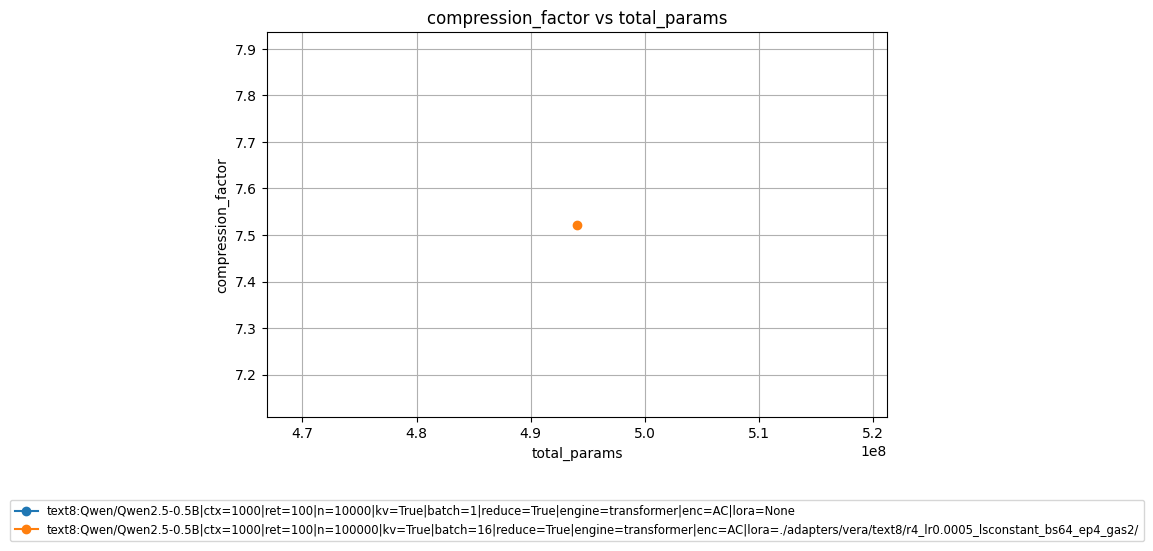

In [10]:
plt.figure(figsize=(8, 5))

for run_key in df["run_key"].unique():
    run_df = df[df["run_key"] == run_key]

    plt.plot(
        run_df[x_col],
        run_df[y_col],
        marker="o",
        label=run_key,
    )

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"{y_col} vs {x_col}")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=1,
    fontsize="small",
)

plt.grid(True)

if save_path:
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Saved plot to {save_path}")

plt.show()